## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Reading Dataset

In [2]:
df = pd.read_csv('Iris.csv')

## Analyzing Data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [4]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

In [5]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [7]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Visualizing Data

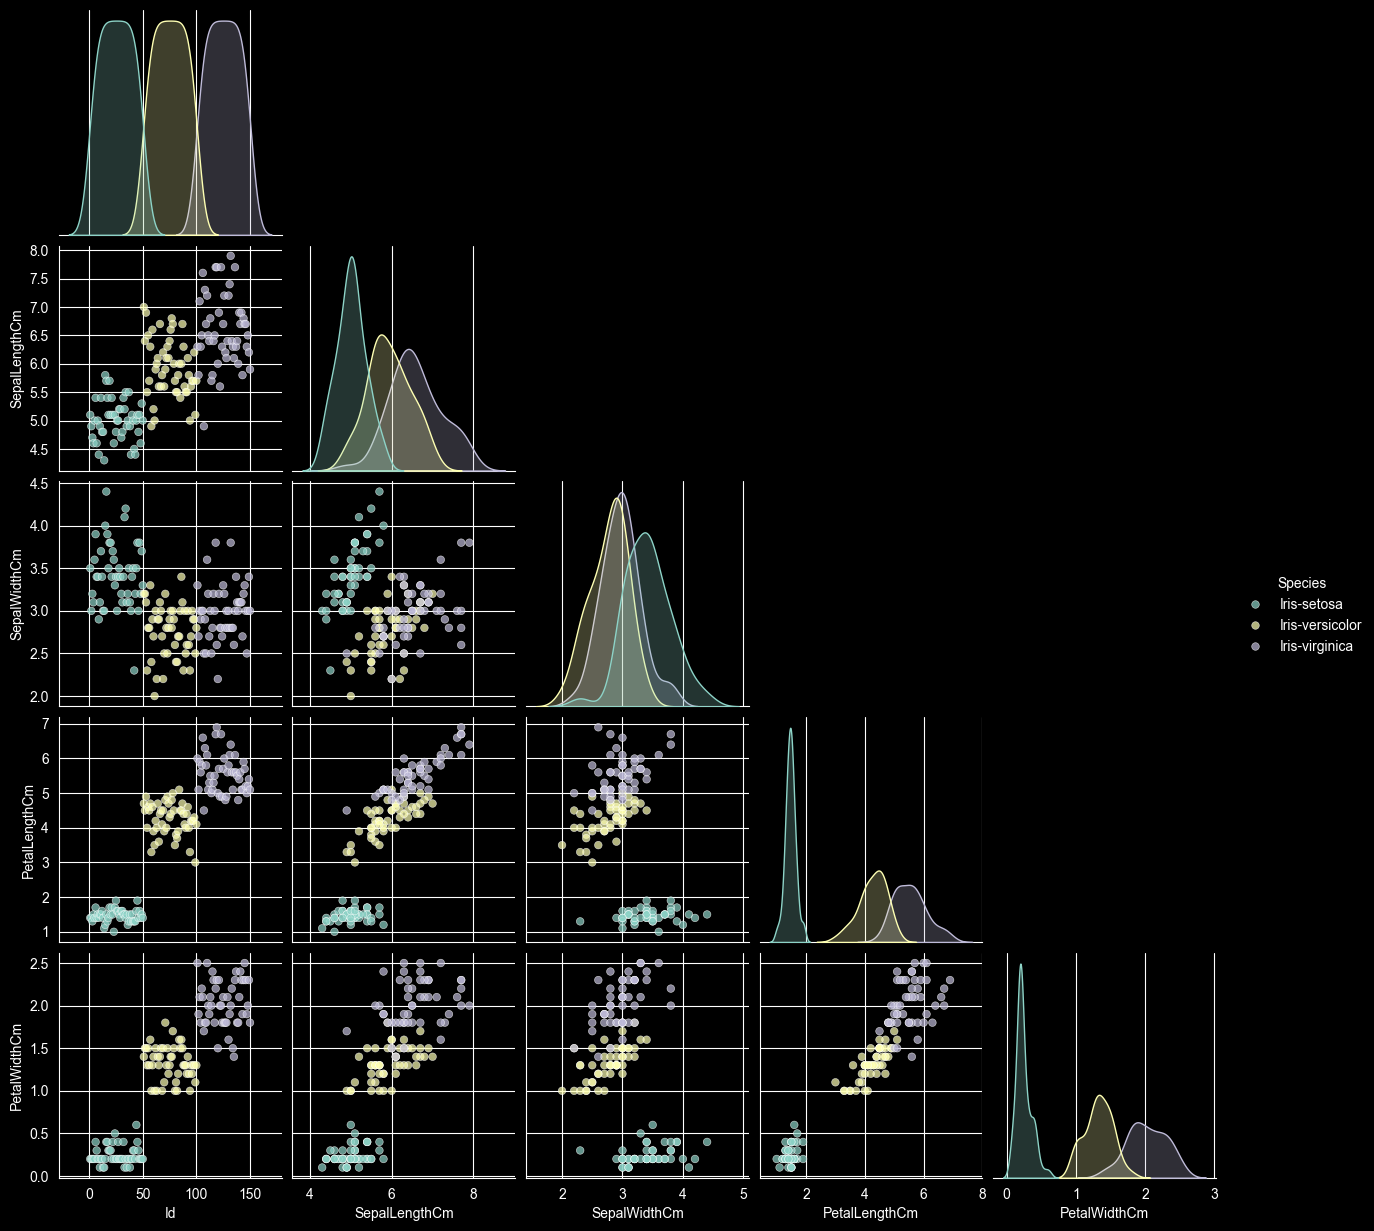

In [9]:
sns.pairplot(df, hue="Species", diag_kind="kde", corner=True,
             plot_kws={"alpha":0.7, "s":30, "edgecolor":"white"})
plt.show()

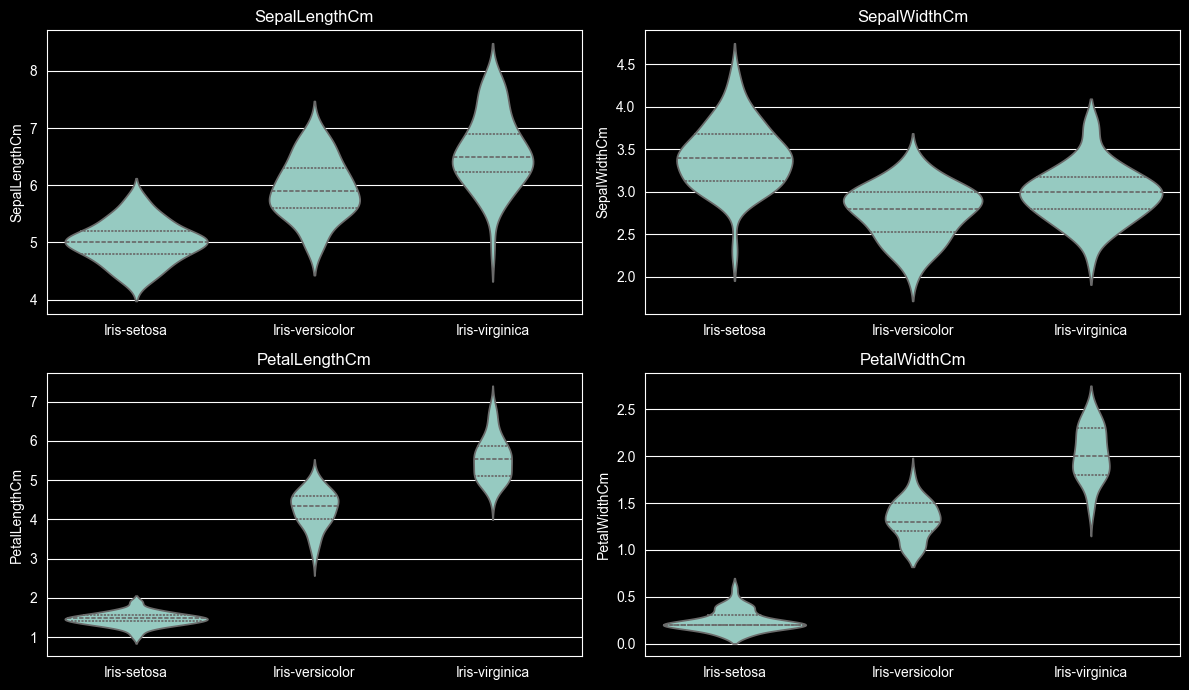

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12,7))
features = ["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]
for ax, f in zip(axes.ravel(), features):
    sns.violinplot(data=df, x="Species", y=f, inner="quartile", ax=ax)
    ax.set_xlabel(""); ax.set_title(f)


plt.tight_layout()
plt.show()

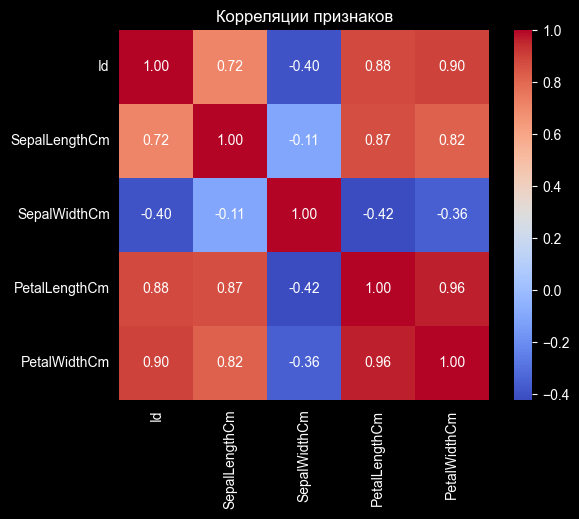

In [11]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Корреляции признаков")
plt.show()

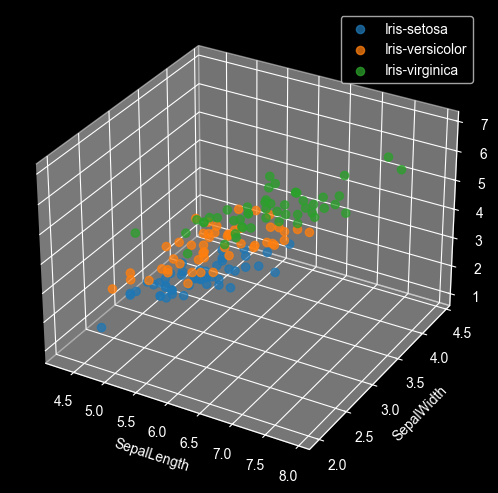

In [12]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection="3d")
colors = dict(zip(df["Species"].unique(), sns.color_palette("tab10", 3)))
for sp, d in df.groupby("Species"):
    ax.scatter(d.SepalLengthCm, d.SepalWidthCm, d.PetalLengthCm,
               s=35, alpha=0.75, color=colors[sp], label=sp)
ax.set_xlabel("SepalLength"); ax.set_ylabel("SepalWidth"); ax.set_zlabel("PetalLength")
ax.legend()

plt.tight_layout()
plt.show()

## Cleaning Data

In [13]:
df = df.drop(columns=['Id', 'PetalWidthCm', 'Species'])

In [14]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(7)

In [16]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm'], dtype='str')

## Splitting Data

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X = df.drop(columns=['PetalLengthCm'])

In [19]:
y = df['PetalLengthCm']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Building Model

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
model = LinearRegression()

In [23]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Predictions

In [24]:
y_pred = model.predict(X_test)

In [25]:
y_pred

array([4.59032802, 2.57157098, 7.67594217, 4.28258932, 5.82539639,
       2.56745744, 3.57683596, 5.60793362, 5.55456858, 4.19231338,
       4.7708799 , 2.03402889, 2.61259541, 2.07916686, 1.51294095,
       4.28670285, 5.03348064, 4.10203744, 3.88457467, 5.11964304,
       1.59498982, 4.32772729, 1.86170409, 5.11964304, 6.45321442,
       5.38635731, 6.04285916, 5.30019491, 2.03402889, 1.90272852,
       0.89335   , 1.78376876, 5.25505694, 1.50882741, 1.0656748 ,
       5.33710581, 4.59444156, 2.0832804 , 1.59910335, 1.29547818,
       4.19231338, 3.62608747, 5.25505694, 1.9109556 , 2.17355633,
       4.05689947, 4.9432047 , 4.72574193, 5.20991898, 5.48074679])

## Evaluation

In [26]:
from sklearn.metrics import r2_score, mean_squared_error

### R2-Score

In [27]:
r2_score(y_test, y_pred)

0.8995388018644789

### MSE

In [28]:
mean_squared_error(y_test, y_pred)

0.3313246480540816

### Errors Visualization

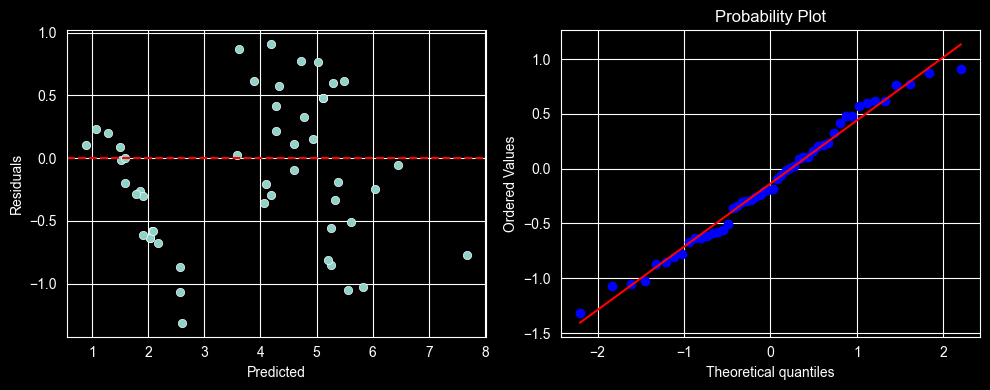

In [29]:
import scipy.stats as stats
resid = y_test - y_pred
fig, ax = plt.subplots(1,2, figsize=(10,4))
sns.scatterplot(x=y_pred, y=resid, ax=ax[0])
ax[0].axhline(0, color="red", ls="--"); ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Residuals")
stats.probplot(resid, dist="norm", plot=ax[1])

plt.tight_layout()
plt.show()

### Conclusion

- В датасете 150 строк и 6 колонок: Id, 4 числовых признака, Species; пропусков и дубликатов нет.

- Описательная статистика (средние/квартили) совпадает с классическим набором Iris, значения лежат в ожидаемых диапазонах.

- Pairplot с оттенением по Species показывает чёткое разделение Setosa по всем признакам; Versicolor и Virginica частично пересекаются, но хорошо разделяются по длине/ширине лепестка.